# NL-PDDL Planner Tutorial: Blockworld with Misalignment

This notebook demonstrates the **NL-PDDL Planner** on a **misaligned Blockworld** problem — where the goal descriptions and domain action descriptions use **different natural language** for the same concepts.

## What is Blockworld?

Blockworld is a classic AI planning domain. You have colored blocks, a table, and a robotic arm. The goal is to rearrange blocks from an initial configuration to a target configuration.


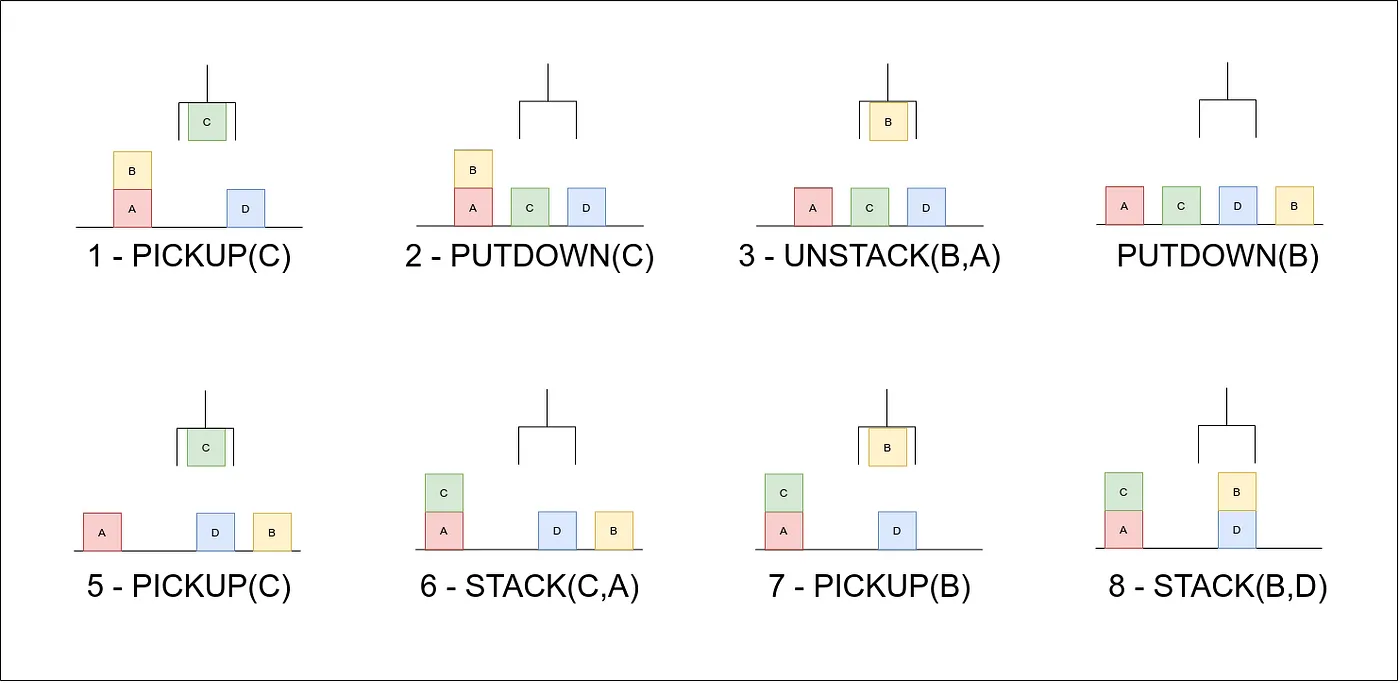

(Diagram based on: [Apoorv Dixit](https://apoorvdixit619.medium.com/goal-stack-planning-for-blocks-world-problem-41779d090f29))

**Rules:**
- The hand can only hold one block at a time.
- You can only pick up or unstack a block if it is "clear" (nothing on top).
- You can stack a block on another only if the target block is clear.

## What is misalignment?

In real-world planning, **goals** are often written by users in their own words, while **domain action definitions** come from a separate action library. The phrasing naturally differs:

| A user's goal might say | The action library says | Same meaning? |
|---|---|---|
| `red is on top of blue` | `block red is directly above block blue` | Yes |
| `I am holding red` | `the agent possesses block red` | Yes |
| `the hand is empty` | `the agent is not holding any objects` | Yes |

A human sees these are equivalent. But a **traditional PDDL planner requires exact string matching** — if the strings differ at all, the planner **cannot connect the goal to any action** and fails.

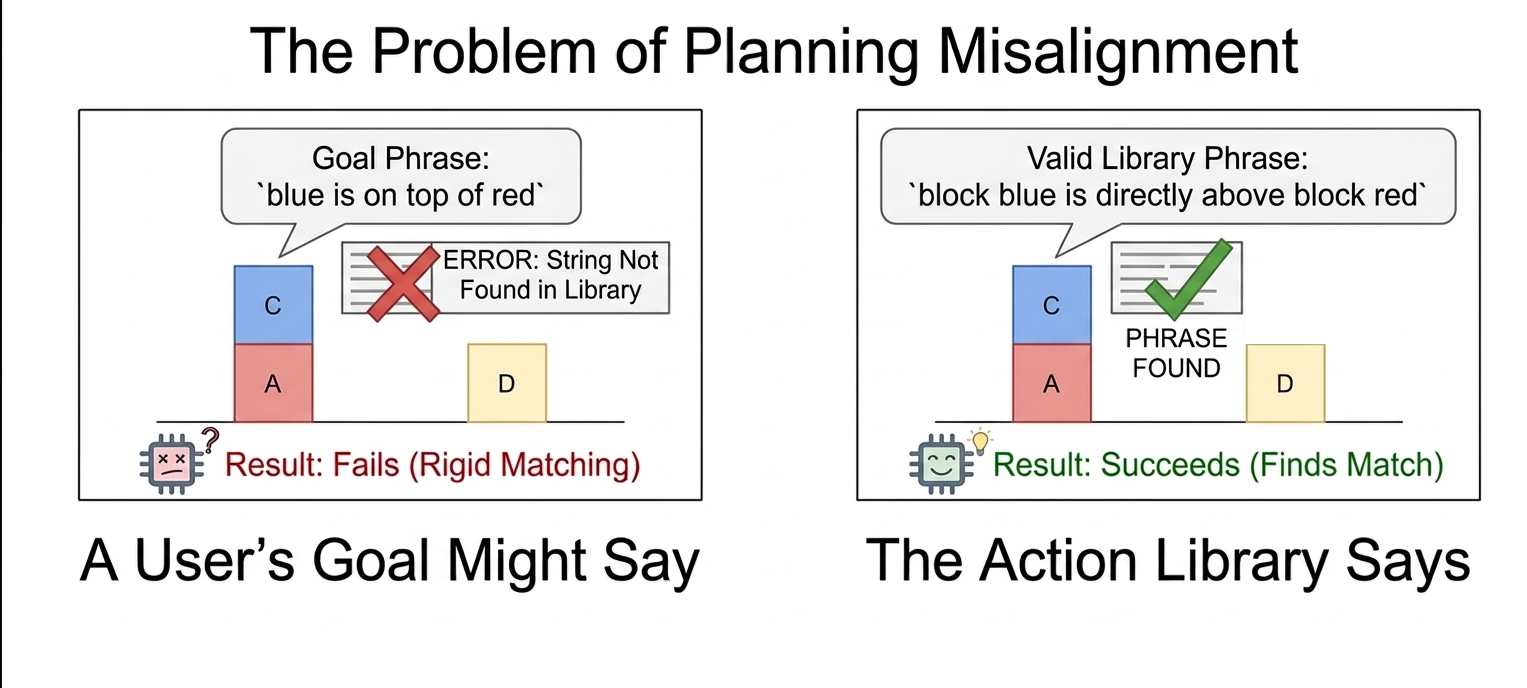

The NL-PDDL Planner solves this by using an **LLM to semantically match** misaligned predicates during regression.

## What you'll learn

1. How to build a misaligned Blockworld domain **from scratch** in Python
2. How to load the same domain from preset JSON files
3. How to visualize block configurations
4. Why traditional PDDL planners fail on misaligned problems
5. How to run the NL-PDDL planner with LLM entailment to solve it
6. How to compare aligned vs misaligned results

## 0. Setup

```bash
pip install -e .
```

Since this tutorial uses the LLM entailment checker, create a `.env` file in the repo root:

```
OPENAI_API_KEY=your-api-key-here
```

In [1]:
import json
import copy
import os
import sys
import tempfile

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from dotenv import load_dotenv
load_dotenv()

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

---
## 1. Building a Misaligned Domain from Scratch

Let's build the entire misaligned Blockworld domain **step by step** in Python. This will teach you the exact JSON structure that the NL-PDDL planner expects, so you can create your own domains for any planning problem.

A domain definition is a **Python list** with two types of entries:
1. **First entry** — a dict containing `"Predicate"`: the list of all predicates (facts) in the world
2. **Remaining entries** — one dict per action, each specifying its name, parameters, preconditions, and effects

### 1.1 Defining Predicates

Predicates describe facts about the world (e.g., "block A is on the table"). Each predicate is a **2-element list**:

```python
["natural language description with ?variables", {"?variable": "type", ...}]
```

- The **first element** is a natural language string. Variables start with `?` (e.g., `?b`, `?b1`).
- The **second element** is a dict mapping each variable to its type. Use `{}` for predicates with no variables.

In [2]:
# Each predicate: ["NL description with ?variables", {"?var": "type"}]

predicates = [
    # No variables — a global fact about the world
    ["the agent is not holding any objects", {}],

    # One variable ?b of type "object" — a property of a single block
    ["block ?b has no block above it", {"?b": "object"}],

    # One variable ?b — where a block is located
    ["block ?b sits directly on the table", {"?b": "object"}],

    # Two variables ?b1, ?b2 — a relationship between two blocks
    ["block ?b1 is directly above block ?b2", {"?b1": "object", "?b2": "object"}],

    # One variable ?b — what the robot arm is holding
    ["the agent possesses block ?b", {"?b": "object"}],
]

# Wrap predicates in the expected structure: first element of the domain list
predicate_entry = {"Predicate": predicates}

print("Defined 5 predicates:")
for p in predicates:
    vars_str = ', '.join(f'{k}: {v}' for k, v in p[1].items()) if p[1] else '(no variables)'
    print(f"  \u2022 '{p[0]}'  [{vars_str}]")

Defined 5 predicates:
  • 'the agent is not holding any objects'  [(no variables)]
  • 'block ?b has no block above it'  [?b: object]
  • 'block ?b sits directly on the table'  [?b: object]
  • 'block ?b1 is directly above block ?b2'  [?b1: object, ?b2: object]
  • 'the agent possesses block ?b'  [?b: object]


### 1.2 Defining Actions

Each action is a dict with these fields:

| Field | Type | Description |
|---|---|---|
| `"Action"` | `str` | Internal action identifier (e.g., `"pick_up"`) |
| `"Action name"` | `[str, dict]` | Human-readable name with parameters |
| `"Parameters"` | `dict` | Variable-to-type mapping for this action |
| `"Preconditions"` | `list` | Predicates that must be true **before** the action |
| `"Effects"` | `dict` | `"Positive"`: predicates that become true; `"Negative"`: predicates that become false |

Preconditions and effects use the **same format** as predicates: `["NL text", {"?var": "type"}]`.


Lets show two examples of actions below:

#### Action 1: `pick_up` — Pick up a block from the table

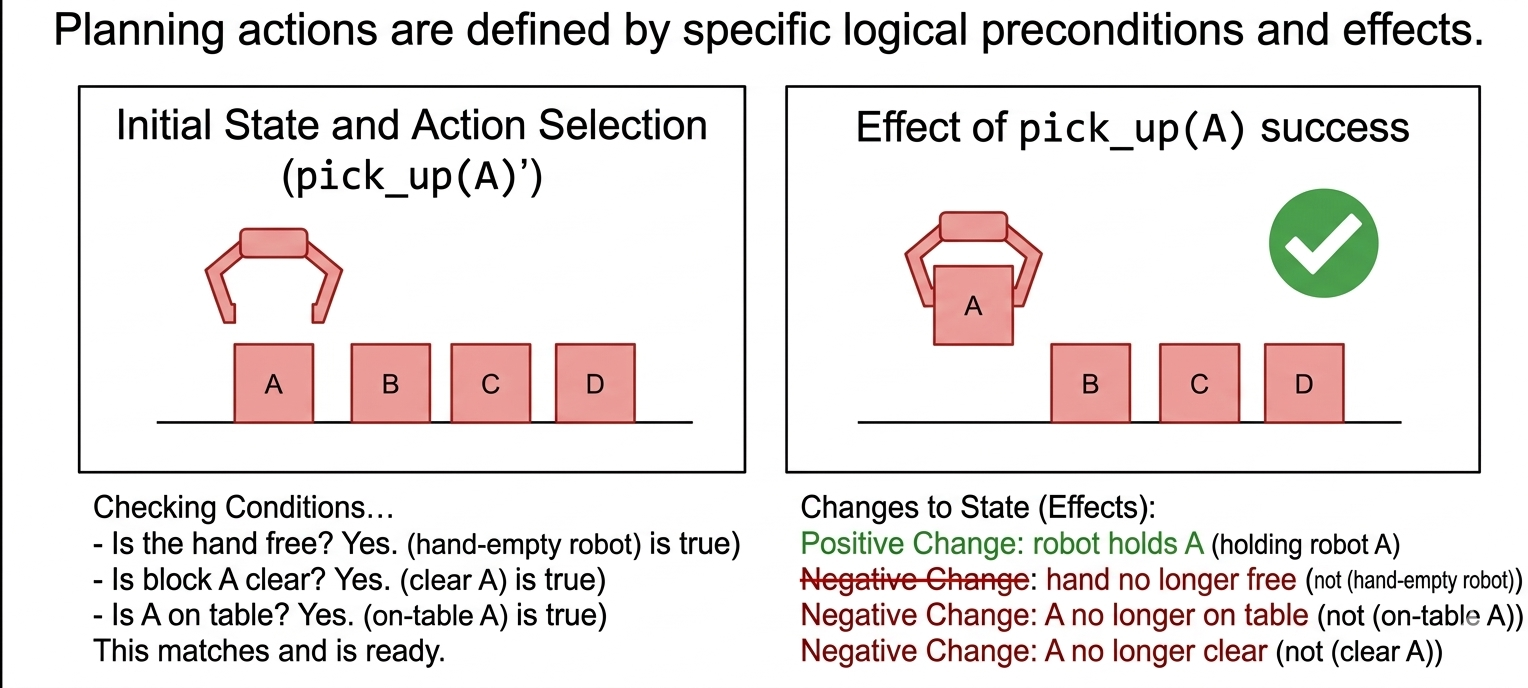

The robot arm picks up a block that is sitting on the table.

- **Preconditions**: hand is free, block is clear, block is on the table
- **Positive effect**: robot now holds the block
- **Negative effects**: hand is no longer free, block is no longer clear or on the table

In [3]:
pick_up = {
    "Action": "pick_up",
    "Action name": ["pick up block ?b", {"?b": "object"}],
    "Parameters": {"?b": "object"},
    "Preconditions": [
        ["the agent is not holding any objects", {}],          # hand must be free
        ["block ?b has no block above it", {"?b": "object"}],  # block must be clear
        ["block ?b sits directly on the table", {"?b": "object"}],  # block must be on table
    ],
    "Effects": {
        "Positive": [
            ["the agent possesses block ?b", {"?b": "object"}],  # now holding it
        ],
        "Negative": [
            ["the agent is not holding any objects", {}],          # hand no longer free
            ["block ?b has no block above it", {"?b": "object"}],  # no longer "clear" (being held)
            ["block ?b sits directly on the table", {"?b": "object"}],  # no longer on table
        ],
    },
}

print(f"Action: {pick_up['Action name'][0]}")
print(f"  Pre:  {[p[0] for p in pick_up['Preconditions']]}")
print(f"  +Eff: {[e[0] for e in pick_up['Effects']['Positive']]}")
print(f"  -Eff: {[e[0] for e in pick_up['Effects']['Negative']]}")

Action: pick up block ?b
  Pre:  ['the agent is not holding any objects', 'block ?b has no block above it', 'block ?b sits directly on the table']
  +Eff: ['the agent possesses block ?b']
  -Eff: ['the agent is not holding any objects', 'block ?b has no block above it', 'block ?b sits directly on the table']


#### Action 2: `put_down` — Put a block down on the table

The robot arm places the block it's holding onto the table.

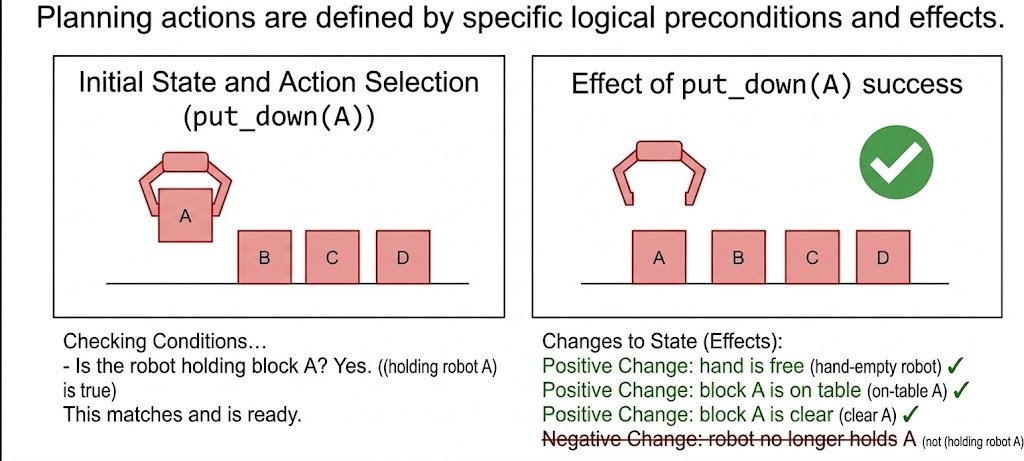


- **Precondition**: robot must be holding the block
- **Positive effects**: hand is free, block is on the table and clear
- **Negative effect**: robot no longer holds the block

In [4]:
put_down = {
    "Action": "put_down",
    "Action name": ["put down block ?b", {"?b": "object"}],
    "Parameters": {"?b": "object"},
    "Preconditions": [
        ["the agent possesses block ?b", {"?b": "object"}],  # must be holding it
    ],
    "Effects": {
        "Positive": [
            ["the agent is not holding any objects", {}],            # hand is free again
            ["block ?b sits directly on the table", {"?b": "object"}],  # block is on table
            ["block ?b has no block above it", {"?b": "object"}],   # block is clear
        ],
        "Negative": [
            ["the agent possesses block ?b", {"?b": "object"}],  # no longer holding it
        ],
    },
}

print(f"Action: {put_down['Action name'][0]}")
print(f"  Pre:  {[p[0] for p in put_down['Preconditions']]}")
print(f"  +Eff: {[e[0] for e in put_down['Effects']['Positive']]}")
print(f"  -Eff: {[e[0] for e in put_down['Effects']['Negative']]}")

Action: put down block ?b
  Pre:  ['the agent possesses block ?b']
  +Eff: ['the agent is not holding any objects', 'block ?b sits directly on the table', 'block ?b has no block above it']
  -Eff: ['the agent possesses block ?b']


There are many other actions (e.g., stacking one block on another), but these two illustrate the structure well. You can define the rest similarly.

### 1.3 Assembling the Complete Domain

The full domain is a list: `[predicate_entry, action1, action2, ...]`

In [5]:
# Assemble the complete domain
misaligned_domain = [predicate_entry, pick_up, put_down]

print(f"Domain assembled: {len(misaligned_domain) - 1} actions")
print(f"Predicates: {len(misaligned_domain[0]['Predicate'])}")
for entry in misaligned_domain[1:]:
    print(f"  Action: {entry['Action name'][0]}")

Domain assembled: 2 actions
Predicates: 5
  Action: pick up block ?b
  Action: put down block ?b


### 1.4 Defining Goals and Initial State

Goals and initial states use the **same predicate format** as the domain, but with **concrete values** instead of `?variables`. 

Let's see the following example below:

Each `init_state` and `goal` is a list of grounded predicates.


In [6]:
# Define the initial state in the USER's natural language
# (This is how a user would describe the current block arrangement)
init_state = [
    ["red is clear",               {"red": "object"}],                     # nothing on top of red
    ["yellow is clear",            {"yellow": "object"}],                  # nothing on top of yellow
    ["the hand is empty",          {}],                                     # robot arm is free
    ["red is on top of blue",      {"red": "object", "blue": "object"}],   # red is stacked on blue
    ["yellow is on top of orange", {"yellow": "object", "orange": "object"}],  # yellow on orange
    ["blue is on the table",       {"blue": "object"}],                    # blue is on the table
    ["orange is on the table",     {"orange": "object"}],                  # orange is on the table
]

This is called **grounding** — replacing variables with actual block names.

Domain predicate (with variables):
`["block ?b1 is directly above block ?b2", {"?b1": "object", "?b2": "object"}]`

Grounded goal predicate (with constants):
`["orange is on top of red", {"orange": "object", "red": "object"}]`

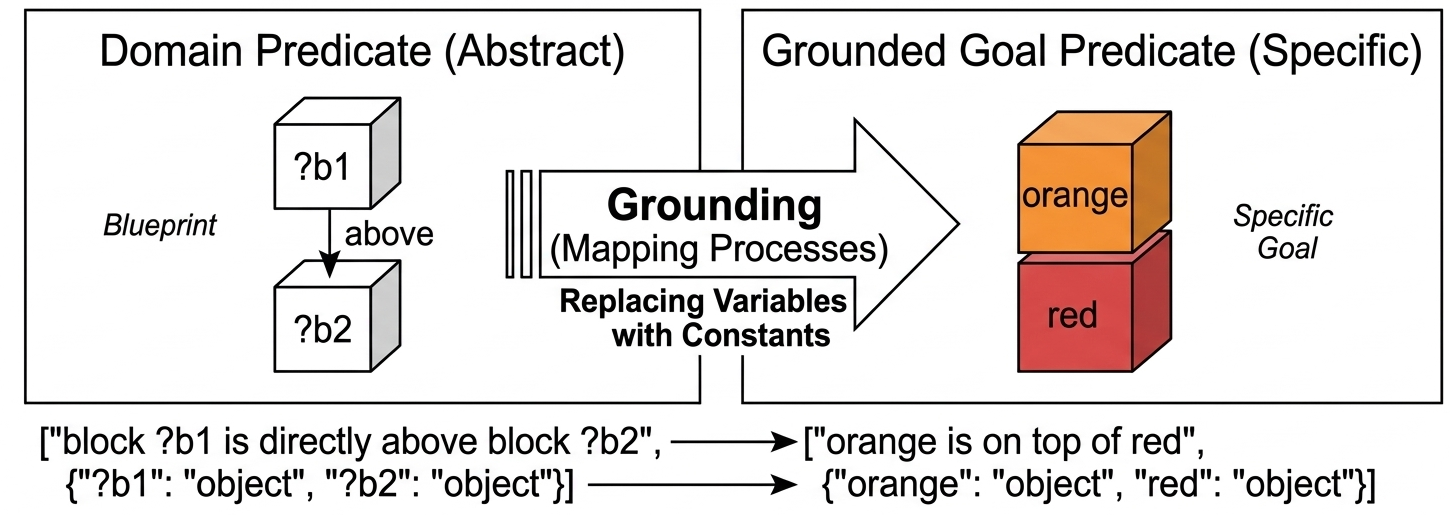


The goal is also a list of predicates, since there can be multiple predicates in the goal (e.g., "orange is on top of red" AND "red is on top of blue") which are the subgoals.

In [7]:
# Define the goal in the USER's natural language
goal = [
    ["orange is on top of red", {"orange": "object", "red": "object"}],
]


**This is where misalignment happens.** The domain says `"block ?b1 is directly above block ?b2"` but the user writes `"orange is on top of red"`. Same meaning, different words. The goal says 'is on top of' but the domain says 'is directly above'. This mismatch is the misalignment that traditional planners cannot handle.

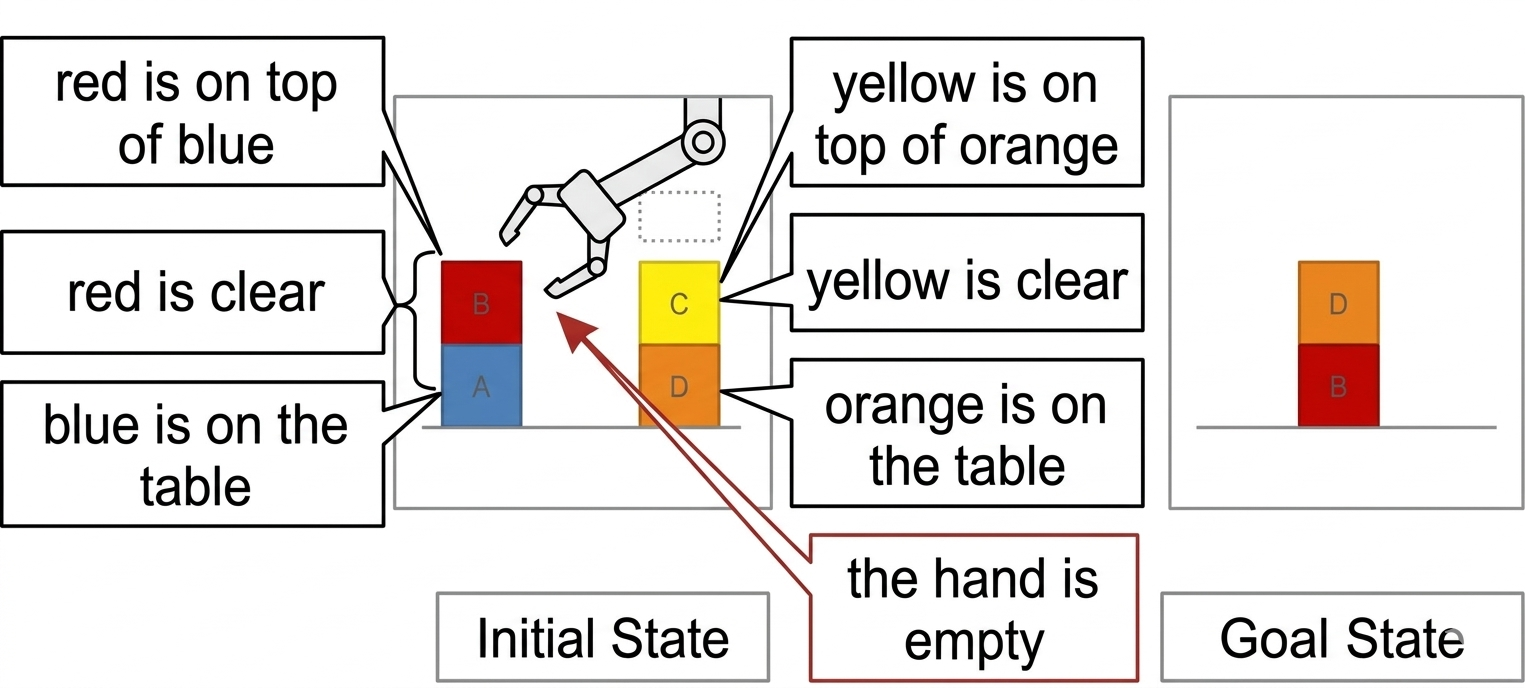

---
## 2. Loading the Domain and Goals from Preset JSON Files

above are some examples of how to build a misaligned Blockworld domain from scratch. But you don't have to do this every time! 

The package ships with preset JSON files under `files/` so you don't have to define domains from scratch every time. The misaligned domain we just built by hand is available as:

- **Domain**: `files/misalignment_blockworld/misalignment_blockworld_model.json`
- **Goals**: `files/blockworld/blockworld_goal.json`

Let's first load the json files


In [8]:
# Load the MISALIGNED domain from the preset JSON file
with open(os.path.join(repo_root, 'files/misalignment_blockworld/misalignment_blockworld_model.json'), 'r') as f:
    misaligned_domain = json.load(f)

# Load all goal problems from the preset JSON file
with open(os.path.join(repo_root, 'files/blockworld/blockworld_goal.json'), 'r') as f:
    all_goals = json.load(f)
    
print(f'Loaded predicates: {len(misaligned_domain[0]["Predicate"])}')
print(f"Loaded domain {len(misaligned_domain) - 1} actions")
print(f"Loaded {len(all_goals)} goal problems")

Loaded predicates: 5
Loaded domain 4 actions
Loaded 500 goal problems


Domain files contains both predicates and actions. The first entry is the predicates

In [9]:
misaligned_domain[0] # this is the predicate definitions in the domain file

{'Predicate': [['the agent is not holding any objects', {}],
  ['block ?b has no block above it', {'?b': 'object'}],
  ['block ?b sits directly on the table', {'?b': 'object'}],
  ['block ?b1 is directly above block ?b2',
   {'?b1': 'object', '?b2': 'object'}],
  ['the agent possesses block ?b', {'?b': 'object'}]]}

and the rest are actions

In [10]:
misaligned_domain[1]  # this is the first action definition in the domain file

{'Action': 'pick_up',
 'Action name': ['pick up block ?b', {'?b': 'object'}],
 'Parameters': {'?b': 'object'},
 'Preconditions': [['the agent is not holding any objects', {}],
  ['block ?b has no block above it', {'?b': 'object'}],
  ['block ?b sits directly on the table', {'?b': 'object'}]],
 'Effects': {'Positive': [['the agent possesses block ?b', {'?b': 'object'}]],
  'Negative': [['the agent is not holding any objects', {}],
   ['block ?b has no block above it', {'?b': 'object'}],
   ['block ?b sits directly on the table', {'?b': 'object'}]]}}

Goal files contain a list of problems, where each problem is a pair of `[init_state, goal]`. 

In [11]:
goal_init_1 = all_goals[0]  # this is the first goal problem: [init_state, goal]
print("=" * 50)
print("Init state:")
init_state_1 = goal_init_1[0]  # this is the init state for the first goal problem
for state in init_state_1:    
    print(f"- '{state}'")
print("=" * 50)
print("Goal:")
goal_1 = goal_init_1[1]  # this is the subgoal for the first goal problem
for subgoal in goal_1:
    print(f"  - '{subgoal}'")

Init state:
- '['red is clear', {'red': 'object'}]'
- '['yellow is clear', {'yellow': 'object'}]'
- '['the hand is empty', {}]'
- '['red is on top of blue', {'red': 'object', 'blue': 'object'}]'
- '['yellow is on top of orange', {'yellow': 'object', 'orange': 'object'}]'
- '['blue is on the table', {'blue': 'object'}]'
- '['orange is on the table', {'orange': 'object'}]'
Goal:
  - '['orange is on top of red', {'orange': 'object', 'red': 'object'}]'


# 3. Loading Domain and Goals in NL-PDDL Planner

Above `misaligned_domain` contains a list of dicts as the domain definition, and `all_goals` is a list of `[init_state, goal]` pairs. NL-PDDL Planner provides a utility function to load domain and goal files:

In [12]:
from pddl_planner.pddl_core.nl_domain import NLDomain
from pddl_planner.logic.nl_parser import NLParser

# Parse the misaligned domain to get internal predicate names
mis_domain_obj = NLDomain(copy.deepcopy(misaligned_domain))

domain_pred_names = {p.name: p.nl_description for p in mis_domain_obj.predicates}
for name, nl in domain_pred_names.items():
    print(f"  '{name}'  (NL: '{nl}')")


  'the agent is holding any objects'  (NL: 'the agent is holding any objects')
  'block  has no block above it'  (NL: 'block ?b has no block above it')
  'block  sits directly on the table'  (NL: 'block ?b sits directly on the table')
  'block  is directly above block'  (NL: 'block ?b1 is directly above block ?b2')
  'the agent possesses block'  (NL: 'the agent possesses block ?b')


All natural language predicates in given format can be prased by NL-PDDL's internal parser into `NLPredicate` objects, which have two important attributes:
- `nl_description`: the original natural language description of the predicate (e.g., "block ?b1 is directly above block ?b2")
- `name`: the internal name that NL-PDDL uses to represent this predicate (e.g., "above(?b1, ?b2)")

In [13]:
# Parse the goal predicate written in standard language
parser = NLParser()

# goal_1 is a list of predicates (subgoals), we parse each predicate in the goal
for pred in goal_1:
    # load the goal predicate in standard language and parse it to nl-pddl's internal representation to get the internal name
    pred = parser.parse_predicate(pred)
    print(type(pred))
    print("GOAL PREDICATE")
    print(f"  NL text:        '{pred.nl_description}'")
    print(f"  Internal name:  '{pred.name}'")



<class 'pddl_planner.logic.nl_formula.NLPredicate'>
GOAL PREDICATE
  NL text:        'orange is on top of red'
  Internal name:  'is on top of'


Let's consider this example and trace through exactly what a conventional PDDL planner tries to do:

```
Goal:   "orange is on top of red"
        Internal predicate name: "is on top of"

Step 1: Look up "is on top of" in SSA table
        SSA table keys (from misaligned domain):
          - "the agent is not holding any objects"    (no match)
          - "block has no block above it"             (no match)
          - "block sits directly on the table"        (no match)
          - "block is directly above block"           (no match!)
          - "the agent possesses block"               (no match)

Step 2: No match found --> cannot regress --> FAIL
```

The predicate `"is on top of"` and `"block is directly above block"` mean the same thing, but the traditional planner treats them as unrelated because the strings are different.

---
## 4. Running the NL-PDDL Planner

Now that we understand the domain, goals, and the misalignment problem, let's use the `NLFOLRegressionPlanner` class to actually solve the problem.

When the planner encounters a goal predicate that doesn't match any domain predicate by name, it:

1. **Calls an LLM** asking: *"Does `orange is on top of red` entail `block orange is directly above block red`?"*
2. Performs **self-consistency voting** (5 queries, majority vote) for robustness
3. If entailment is confirmed, **maps** the goal predicate to the domain predicate's SSA
4. **Regression proceeds** normally with the matched predicate

This section walks through every step of using the planner class.

### 4.1 Import and API Key Setup

The main entry point is `NLFOLRegressionPlanner` from `pddl_planner.planner.nl_planner`.

Since the planner uses an LLM for semantic entailment, you need an OpenAI-compatible API key. The planner will fall back to `os.getenv('OPENAI_API_KEY')` if you don't pass one explicitly.

In [14]:
from pddl_planner.planner.nl_planner import NLFOLRegressionPlanner
import logging

# Load your API key (set in .env or environment)
api_key = os.environ.get('OPENAI_API_KEY')

if not api_key:
    print("WARNING: OPENAI_API_KEY not set. Set it in .env to run this demo.")
    print("The cells below will be skipped, but comments explain what would happen.")
else:
    print(f"API key loaded (ends with ...{api_key[-4:]})")

API key loaded (ends with ...v18A)


### 4.2 Creating the Planner

The `NLFOLRegressionPlanner` constructor takes the domain and goal we defined earlier, plus several configuration parameters.

Here is the full parameter reference:

| Parameter | Type | Default | Description |
|---|---|---|---|
| `nl_domain` | `list` | *required* | The domain definition (list of predicate dict + action dicts) |
| `nl_problem` | `list` | *required* | The goal predicates (list of `["NL text", {vars}]`) |
| `nl_init` | `list` or `None` | `None` | Initial state predicates. `None` means the planner skips init-state simplification |
| `max_depth` | `int` | `16` | Maximum regression depth. Higher = finds longer plans but slower. Start with 3-6 for simple problems |
| `llm_model` | `str` | `"gpt-4o-mini"` | Any OpenAI-compatible model name. Cheaper models work well for entailment |
| `llm_api_key` | `str` | `None` | API key. If `None`, reads from `OPENAI_API_KEY` env var |
| `verbose` | `bool` | `True` | Show planner progress logs (depth, frontier size, timing) |
| `llm_verbose` | `bool` | `False` | Show LLM-level logs (entailment queries, cache hits, vote results) |
| `log_path` | `str` or `None` | `None` | Path to write logs to a file (in addition to console) |
| `time_limit` | `int` or `None` | `None` | Max seconds per problem. `None` = no limit |
| `cache_path` | `str` or `None` | `None` | Path to JSON file for caching LLM responses. Avoids repeated API calls for the same entailment query |

**Important:** Always pass `copy.deepcopy()` of your domain and goal, because the planner modifies them internally.

Lets Consider the domain and the first goal shown "orange is on top of red"

In [15]:
if api_key:
    # Create a temporary file to save the plan output
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
        save_path = f.name

    planner = NLFOLRegressionPlanner(
        # --- Required: domain and goal ---
        nl_domain=copy.deepcopy(misaligned_domain),  # the domain we loaded from JSON in Section 2
        nl_problem=copy.deepcopy(goal_1),             # the goal predicates (e.g., "orange is on top of red")
        nl_init=None,                                 # no initial state provided (optional)

        # --- Search configuration ---
        max_depth=4,          # how deep to search (6 is enough for most blockworld problems)

        # --- LLM configuration ---
        llm_model="gpt-5.4-mini",  # fast & cheap model; works well for entailment checks
        llm_api_key=api_key,       # your OpenAI-compatible API key

        # --- Logging ---
        verbose=True,        # show planner progress: depth, frontier, timing
        llm_verbose=True,    # show LLM details: entailment queries, votes, cache hits
                             # set to False to reduce noise once you understand the flow

        # --- Optional ---
        log_path="planner.log",       # write logs to file
        time_limit=60,                # stop after 60 seconds
        cache_path="llm_cache.json",  # cache LLM responses to avoid repeated API calls
    )

    print("Planner created successfully.")
    print(f"  Domain: {len(misaligned_domain) - 1} actions, {len(misaligned_domain[0]['Predicate'])} predicates")
    print(f"  Goal: {[g[0] for g in goal_1]}")
    print(f"  Max depth: 6")

Planner created successfully.
  Domain: 4 actions, 5 predicates
  Goal: ['orange is on top of red']
  Max depth: 6


The initialization will parse the natural language predicates into internal `NLPredicate` objects, build the SSA for domain predicates, and prepare the goal predicates for regression.

### 4.3 Running the Planner

Call `planner.regress_plan()` to start the regression search. This is the main entry point that:

1. Converts the goal to Disjunctive Normal Form (DNF)
2. Iteratively regresses through each action in the domain
3. When a predicate name mismatch is detected, invokes the LLM for entailment
4. Returns a list of `(subgoal, actions, substitution)` tuples

The `save_file_path` parameter writes each discovered subgoal to a text file as it's found.

**What to watch in the logs:**
- `pddl_planner.planner | INFO | Depth X/Y` — regression progress
- `pddl_planner.llm | INFO | Checking entailment` — LLM is resolving a mismatch
- `pddl_planner.llm | INFO | Entailment vote` — self-consistency voting result (e.g., 5/5 yes)
- `pddl_planner.planner | INFO | Regression complete` — final summary with timing and stats

In [16]:
if api_key:
    # Run the regression planner
    plans = planner.regress_plan(
        save_file_path=save_path,  # write subgoals to this file as they're discovered
    )

Starting regression | max_depth=4 | time_limit=60 | 4 actions in domain
Logs are being written to: planner.log
Regression complete | 49.35s | 51 subgoals | 56 missing-predicate lookups
LLM stats: 10 API calls | avg latency 0.7648s | 72 cache hits
Full log saved to: planner.log


In [17]:
# --- Summary ---
if api_key:
    print(f"\n{'=' * 60}")
    print(f"Found {len(plans)} subgoal(s).")
    print(f"Predicates resolved via LLM entailment: {planner._missing_name_count}")
    print(f"LLM API calls: {planner._llm.api_call_count}")
    print(f"LLM cache hits: {planner._llm.cache_call_count}")
    if planner._llm.api_latency_count > 0:
        avg = planner._llm.api_latency_sum / planner._llm.api_latency_count
        print(f"LLM avg latency: {avg:.3f}s")


Found 51 subgoal(s).
Predicates resolved via LLM entailment: 56
LLM API calls: 10
LLM cache hits: 72
LLM avg latency: 0.765s


# 5 Interpreting the Results

The `regress_plan()` method returns a list of tuples. Each tuple represents one discovered subgoal:

In [ ]:
if api_key:
    for i, (subgoal, actions, substitution) in enumerate(plans):
        # Reverse actions to get forward order, and ground variables with substitution
        grounded_actions = [str(a.substitute(substitution)) for a in reversed(actions)]

        print(f"\n--- Subgoal S{i} ---")
        if grounded_actions:
            print(f"  Actions (forward order): {grounded_actions}")
        else:
            print(f"  Actions: (none — this is the initial goal)")
        print(f"  Subgoal formula: {subgoal}")
        if substitution:
            print(f"  Variable bindings: {substitution}")
        
        if  i > 5:
            # print the first 5 subgoals
            print("Ommitting...")
            break


--- Subgoal S0 ---
  Actions: (none — this is the initial goal)
  Subgoal formula: ((is on top of(orange, red)))

--- Subgoal S1 ---
  Actions (forward order): ["Action('stack block ?b1 on block ?b2'(orange, red))"]
  Subgoal formula: ((block  has no block above it(red) ∧ the agent possesses block(orange)))
  Variable bindings: {?V32: orange, ?V33: red}

--- Subgoal S2 ---
  Actions (forward order): ["Action('pick up block ?b'(orange))", "Action('stack block ?b1 on block ?b2'(orange, red))"]
  Subgoal formula: ((block  has no block above it(orange) ∧ block  has no block above it(red) ∧ block  sits directly on the table(orange) ∧ not the agent is holding any objects()))
  Variable bindings: {?V32: orange, ?V33: red, ?V36: orange}

--- Subgoal S3 ---
  Actions (forward order): ["Action('put down block ?b'(red))", "Action('stack block ?b1 on block ?b2'(orange, red))"]
  Subgoal formula: ((the agent possesses block(orange) ∧ the agent possesses block(red)))
  Variable bindings: {?V32: ora

#### Reading the output


Each `--- Subgoal S{n} ---` block represents one node in the regression search tree. Let's walk through **S2** as an example:

```
--- Subgoal S2 ---
  Actions (forward order): ["Action('pick up block ?b'(orange))", "Action('stack block ?b1 on block ?b2'(orange, red))"]
  Subgoal formula: ((block  has no block above it(orange) ∧ block  has no block above it(red) ∧ block  sits directly on the table(orange) ∧ not the agent is holding any objects()))
  Variable bindings: {?V32: orange, ?V33: red, ?V36: orange}
```

| Line | Meaning |
|---|---|
| `Subgoal S2` | The identifier for this node in the regression tree. Subgoals are numbered in BFS discovery order — **S0** is always the original goal. |
| `Actions (forward order)` | The full action sequence that, if executed from left to right starting in a state satisfying the subgoal formula, will achieve the original goal. Here: first **pick up orange**, then **stack orange on red**. |
| ` Subgoal formula` | The conjunction of predicates that must hold *before* the first action fires. Each conjunct separated by `∧` is one required condition. In this example the world needs: orange is clear, red is clear, orange is on the table, and the agent's hand is empty. |
| `Variable bindings` | Maps planner-internal variable names (e.g., `?V36`) to the objects they were unified with during regression. This is how the planner tracks which objects fill each action parameter. |

**Special cases:**

- **S0** has an empty action list (`(none)`) because it *is* the goal — no actions are needed if the goal already holds.
- Some subgoals contain **unbound variables** (e.g., `?V40` in S4). These represent partially grounded plans where the planner has not yet committed to a specific object; they will be further refined as regression continues.
- A subgoal with a **`!=` constraint** (e.g., `?V46 != orange` in S7) means the planner determined that a particular binding would be invalid (it would undo the goal), so it excluded it.

### 4.5 Visualizing the Regression Tree

The saved plan file can be visualized as an **interactive regression tree** using the built-in `plan_viewer` tool. In goal-first-order regression planning, the tree grows from the **Goal** node (S0) outward: each child is produced by regressing its parent's subgoal through a domain action, generating new preconditions that must hold for that action sequence to achieve the goal.

**Key concepts in the viewer:**

- **Goal (root):** The planning goal — S0 with no actions.
- **Each child node:** A subgoal created by regressing through one action. The edge label shows which action was applied.
- **Depth:** How many regression steps separate the node from the goal. Deeper nodes correspond to longer plans.
- **Execution plan:** Clicking a node shows the forward execution order — the sequence of actions from that node's preconditions all the way to the goal.
- **Iteration slider:** Replay the BFS exploration order (S0, S1, S2, …) to watch the tree grow as the planner discovers subgoals.
- **Collapsible nodes:** Double-click to expand/collapse subtrees.

**Usage from the command line:**

```bash
# Visualize a single result file
python -m pddl_planner.plan_viewer path/to/result.txt

# Visualize all result files in a directory
python -m pddl_planner.plan_viewer path/to/results_dir/

# Custom output path, skip auto-open
python -m pddl_planner.plan_viewer path/to/result.txt -o viewer.html --no-open
```

Below we generate the viewer and embed it directly in this notebook. You can interact with the tree right here — click nodes, use the slider, zoom and pan. Run the **next cell** to open the same viewer in your default browser for a full-window experience:

In [19]:
#auto reload
%load_ext autoreload
%autoreload 2

In [20]:
if api_key:
    from pddl_planner.plan_viewer import parse_result_file, build_tree, generate_html
    from IPython.display import display, HTML
    import base64, webbrowser

    viewer_output = os.path.join(os.path.dirname(save_path), "plan_viewer_output.html")
    parsed = parse_result_file(save_path)
    print(f"Parsed {len(parsed['subgoals'])} subgoals from the plan file")

    tree = build_tree(parsed)
    max_depth = max((sg["depth"] for sg in parsed["subgoals"]), default=0)
    print(f"Tree root: {tree['label']} with {len(tree['children'])} children, max depth {max_depth}")

    generate_html([parsed], viewer_output)
    _viewer_abs = os.path.abspath(viewer_output)
    print(f"Viewer saved to: {_viewer_abs}\n")

    with open(_viewer_abs, "r", encoding="utf-8") as _f:
        _viewer_html = _f.read()
    _b64 = base64.b64encode(_viewer_html.encode("utf-8")).decode("ascii")
    _data_uri = f"data:text/html;base64,{_b64}"

    display(HTML(
        f'<iframe src="{_data_uri}" width="100%" height="620" '
        f'style="border:1px solid #444;border-radius:8px;"></iframe>'
    ))

    # os.unlink(save_path)
else:
    print("Skipped (no API key). You can run the viewer on pre-computed results:")
    print("  python -m pddl_planner.plan_viewer pddl_planner/tests/results/misalignment_blockworld_results_depth4/")

Parsed 51 subgoals from the plan file
Tree root: S0 with 1 children, max depth 4
Viewer saved to: /var/folders/hg/0kqv54vx6md2kv5y_62z571h0000gn/T/plan_viewer_output.html



/Users/joeliang/Desktop/UofT/Research/PDDL_NL/nl_pddl_planner/nl_pddl/lib/python3.12/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


You can also open the plan viewer in your browser using following code:

In [21]:
if api_key:
    import webbrowser
    webbrowser.open(f"file://{_viewer_abs}")
    print(f"Opened {_viewer_abs} in your default browser for full-window interaction.")

Opened /var/folders/hg/0kqv54vx6md2kv5y_62z571h0000gn/T/plan_viewer_output.html in your default browser for full-window interaction.


### 4.6 The Saved Plan File

If you passed `save_file_path` to `regress_plan()`, each subgoal is appended to that file as it's discovered.
This is useful for long-running problems where you want to inspect partial results.

---
## 7. Using the Command-Line Script

You can run the planner from the terminal. For the misaligned domain:

```bash
# Misaligned domain + standard goals (requires LLM API key in .env)
python pddl_planner/scripts/run_nl_pddl.py \
    --model files/misalignment_blockworld/misalignment_blockworld_model.json \
    --goals files/blockworld/blockworld_goal.json \
    --max_depth 10 \
    --limit 1

# Standard domain (no LLM needed)
python pddl_planner/scripts/run_nl_pddl.py \
    --model files/blockworld/blockworld_model.json \
    --goals files/blockworld/blockworld_goal.json \
    --max_depth 10 \
    --limit 1
```

### CLI Arguments

| Argument | Description | Default |
|---|---|---|
| `--model` | Path to domain model JSON | `files/blockworld/blockworld_model.json` |
| `--goals` | Path to goals JSON | `files/blockworld/blockworld_goal.json` |
| `--max_depth` | Max regression depth | 10 |
| `--time_limit` | Seconds per problem | None |
| `--llm_model` | LLM model name | `gpt-4o-mini` |
| `--llm_api_key` | LLM API key | From `.env` |
| `--output_dir` | Results directory | Auto-generated |
| `--limit` | Number of problems to solve | 1 |

---
## Summary

In this tutorial you:

1. **Built a misaligned domain from scratch** — understanding each field (predicates, actions, effects)
2. **Loaded the same domain from preset JSON files** for convenience
3. **Visualized** the initial state and goal
4. **Understood why traditional PDDL fails** — exact string matching cannot bridge different phrasings
5. **Ran the NL-PDDL planner** which uses LLM entailment to resolve the mismatch
6. **Compared** aligned vs misaligned results side-by-side

### Other domains to explore

| Domain | Path | Description |
|---|---|---|
| Mystery Blocksworld | `files/mystery_blocksworld/` | Completely obfuscated predicate names |
| Randomized Blockworld | `files/randomized_blockworld/` | Random-token predicate names |
| ALFWorld Text | `files/alfworld_text/` | Household task planning |